# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model and recalibrates predictions using isotonic regression for patients with MSI-H metastatic colorectal cancer receiving first-line pembrolizumab or chemotherapy.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/gb_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180', 'psurv_365']]

In [4]:
survival_predictions_df.shape

(37381, 4)

In [5]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_pembrochemo_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [6]:
pembro_pembrochemo_df.shape

(1208, 170)

In [7]:
df = pd.merge(pembro_pembrochemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(1208, 173)

In [9]:
df = df.query('met_diagnosis_year <= 2023')

In [10]:
df.shape

(1074, 173)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.0401, 0.749]",0.546523,0.397849,108,0.296150,0.481687
1,"(0.749, 0.846]",0.808140,0.716981,107,0.620869,0.792757
2,"(0.846, 0.884]",0.868808,0.737910,107,0.641474,0.812159
3,"(0.884, 0.908]",0.896489,0.868396,108,0.786531,0.918943
4,"(0.908, 0.924]",0.916281,0.865330,107,0.774284,0.911944
5,"(0.924, 0.933]",0.928594,0.821138,107,0.721247,0.876327
6,"(0.933, 0.942]",0.937649,0.905263,108,0.820499,0.941406
7,"(0.942, 0.953]",0.947313,0.941528,107,0.870790,0.971393
8,"(0.953, 0.964]",0.958776,0.971335,107,0.907487,0.988061
9,"(0.964, 0.986]",0.971696,0.990566,108,0.933967,0.998283


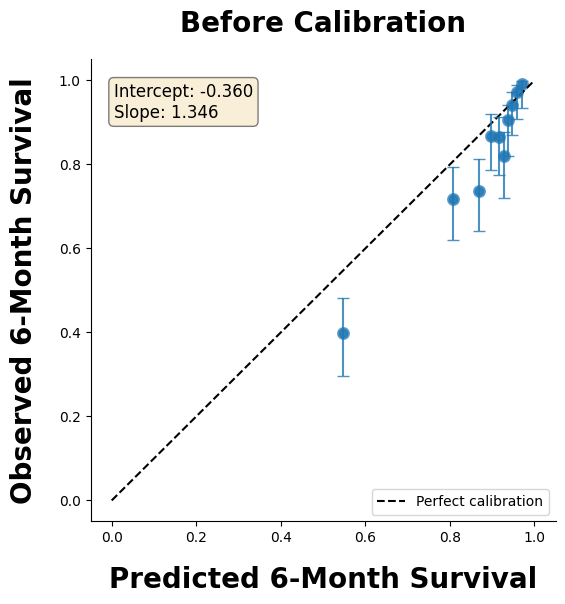

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1311

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1144

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1141

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1238

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1193

=== Summary ===
psurv_180_calibrated computed: 1074

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1206 ± 0.0064


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.564]",0.382030,0.397849,108,0.296150,0.481687
1,"(0.564, 0.712]",0.698045,0.759612,116,0.669338,0.828365
2,"(0.712, 0.839]",0.772724,0.721141,98,0.611946,0.792614
3,"(0.839, 0.842]",0.840669,0.884250,135,0.812331,0.926520
4,"(0.842, 0.856]",0.849045,0.828774,119,0.747210,0.886000
5,"(0.856, 0.866]",0.863948,0.814063,95,0.711676,0.875569
6,"(0.866, 0.943]",0.927225,0.935001,97,0.861023,0.970265
7,"(0.943, 0.966]",0.955658,0.928718,116,0.862515,0.963701
8,"(0.966, 0.985]",0.981770,0.988636,90,0.917877,0.996644
9,"(0.985, 1.0]",0.997089,0.979592,100,0.919259,0.994260


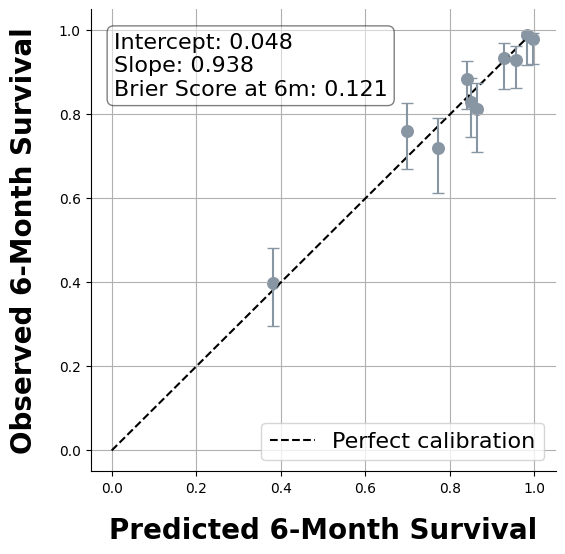

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color='#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/calibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()